In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import pathlib
figures_dir = pathlib.Path(__file__).parent / "figures" if "__file__" in dir() else pathlib.Path("figures")
figures_dir = pathlib.Path(r"C:\Electrical Engineering Planner\Planner Output\Week 1\Week_01_CMOS_Inverter\figures")
figures_dir.mkdir(parents=True, exist_ok=True)

In [6]:
# parameters for 180nm CMOS process
V_DD = 1.8 
V_tn = 0.4         #(NMOS threshold voltage)
V_tp = -0.4        #(PMOS threshold voltage)
k_n = 200     #(NMOS process transconductance, k'_n * W/L)
k_p = 100     #(PMOS process transconductance, k'_p * W/L)
lambda_n = 0.04   #(NMOS channel-length modulation)
lambda_p = 0.04  #(PMOS channel-length modulation)

In [7]:
# I-V characteristics of NMOS transistor
def i_ds_nmos(Vgs, Vds, Vtn=V_tn, kn=k_n, lam=lambda_n):
    """Shockley long-channel NMOS drain current model."""
    Vov = Vgs - Vtn
    if Vov < 0:                        # Cutoff
        return 0.0
    elif Vds < Vov:                    # Linear (Triode)
        return kn * (Vov * Vds - 0.5 * Vds**2) * (1 + lam * Vds)
    else:                              # Saturation
        return 0.5 * kn * Vov**2 * (1 + lam * Vds)

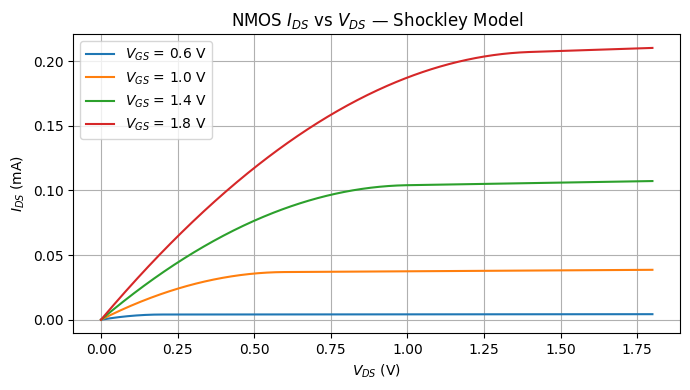

In [8]:
# --- NMOS Verification plot ---
Vds_arr = np.linspace(0, 1.8, 500)
Vgs_list = [0.6, 1.0, 1.4, 1.8]

fig, ax = plt.subplots(figsize=(7, 4))
for Vgs_val in Vgs_list:
    Ids = [i_ds_nmos(Vgs_val, v) * 1e-3 for v in Vds_arr]  # Convert µA to mA
    ax.plot(Vds_arr, Ids, label=f'$V_{{GS}}$ = {Vgs_val} V')

ax.set_xlabel('$V_{DS}$ (V)')
ax.set_ylabel('$I_{DS}$ (mA)')
ax.set_title('NMOS $I_{DS}$ vs $V_{DS}$ — Shockley Model')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(figures_dir / "nmos_iv.png", dpi=150)
plt.show()

In [9]:
#IV characteristics of PMOS transistor
def i_ds_pmos(Vsg, Vsd, Vtp=V_tp, kp=k_p, lam=lambda_p):
    """Shockley long-channel PMOS drain current model."""
    if Vsg < abs(Vtp):                        # Cutoff
        return 0.0
    elif Vsg >= abs(Vtp) and Vsd < Vsg - abs(Vtp):                    # Linear (Triode)
        return kp * ((Vsg - abs(Vtp)) * Vsd - 0.5 * Vsd**2) * (1 + lam * Vsd)
    else:                              # Saturation
        return 0.5 * kp * (Vsg - abs(Vtp))**2 * (1 + lam * Vsd)

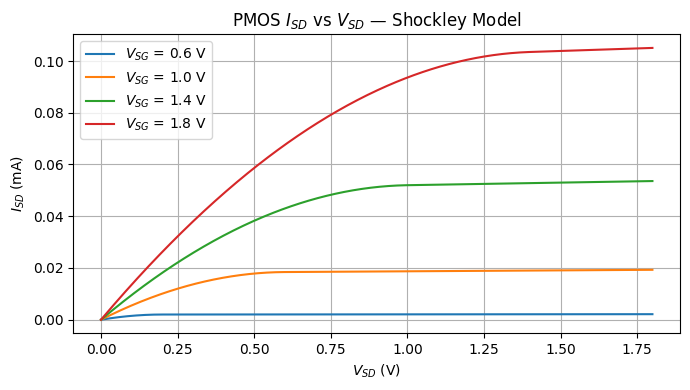

In [10]:
Vsd_arr = np.linspace(0, 1.8, 500)
Vsg_list = [0.6, 1.0, 1.4, 1.8]

fig, ax = plt.subplots(figsize=(7, 4))
for Vsg_val in Vsg_list:
    Isd = [i_ds_pmos(Vsg_val, v) * 1e-3 for v in Vsd_arr]  # Convert µA to mA
    ax.plot(Vsd_arr, Isd, label=f'$V_{{SG}}$ = {Vsg_val} V')

ax.set_xlabel('$V_{SD}$ (V)')
ax.set_ylabel('$I_{SD}$ (mA)')
ax.set_title('PMOS $I_{SD}$ vs $V_{SD}$ — Shockley Model')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(figures_dir / "pmos_iv.png", dpi=150)
plt.show()

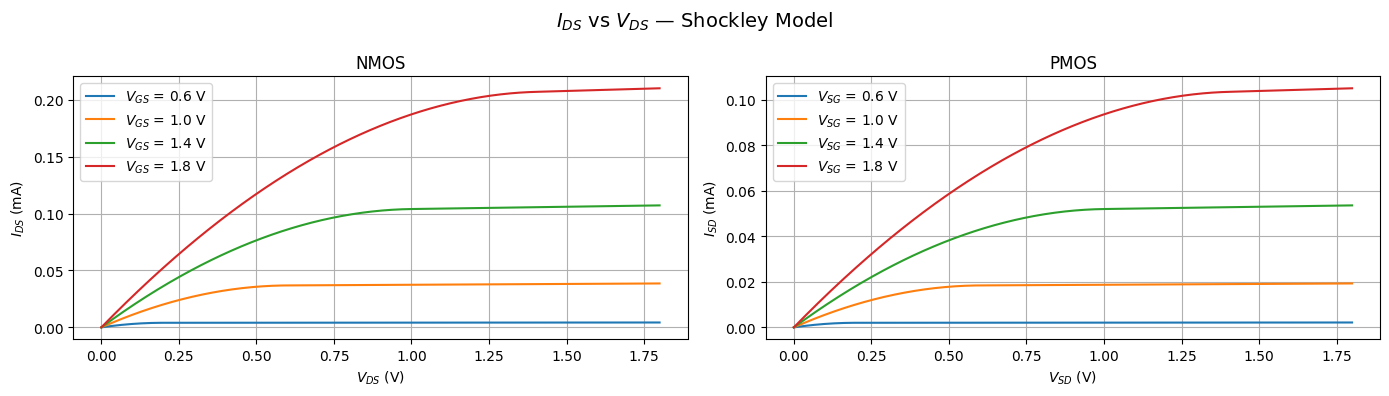

In [11]:
# --- Combined NMOS & PMOS Verification Plot ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# --- NMOS (left) ---
Vds_arr = np.linspace(0, 1.8, 500)
Vgs_list = [0.6, 1.0, 1.4, 1.8]
for Vgs_val in Vgs_list:
    Ids = [i_ds_nmos(Vgs_val, v) * 1e-3 for v in Vds_arr]
    ax[0].plot(Vds_arr, Ids, label=f'$V_{{GS}}$ = {Vgs_val} V')
ax[0].set_xlabel('$V_{DS}$ (V)')
ax[0].set_ylabel('$I_{DS}$ (mA)')
ax[0].set_title('NMOS')
ax[0].legend()
ax[0].grid(True)

# --- PMOS (right) ---
Vsd_arr = np.linspace(0, 1.8, 500)
Vsg_list = [0.6, 1.0, 1.4, 1.8]
for Vsg_val in Vsg_list:
    Isd = [i_ds_pmos(Vsg_val, v) * 1e-3 for v in Vsd_arr]
    ax[1].plot(Vsd_arr, Isd, label=f'$V_{{SG}}$ = {Vsg_val} V')
ax[1].set_xlabel('$V_{SD}$ (V)')
ax[1].set_ylabel('$I_{SD}$ (mA)')
ax[1].set_title('PMOS')
ax[1].legend()
ax[1].grid(True)

fig.suptitle('$I_{DS}$ vs $V_{DS}$ — Shockley Model', fontsize=14)
plt.tight_layout()
plt.savefig(figures_dir / "nmos_pmos_iv_combined.png", dpi=150)
plt.show()

In [12]:
# ── MOSFET Current Models ─────────────────────────────────────

def i_ds_nmos(Vin, Vout, kn=k_n):
    """NMOS drain current (Shockley model). Vgs = Vin, Vds = Vout."""
    Vgs = Vin   # Vgs = Vg - Vs, and Vs = 0 (ground)
    Vds = Vout  # Vds = Vd - Vs, and Vs = 0 (ground)
    if Vgs - V_tn <= 0:
        return 0.0
    elif Vds <= Vgs - V_tn:
        return kn * ((Vgs - V_tn) * Vds - Vds**2 / 2)
    else:
        return kn / 2 * (Vgs - V_tn)**2


def i_ds_pmos(Vin, Vout, kp=k_p):
    """PMOS drain current (Shockley model). Vsg = V_DD - Vin, Vsd = V_DD - Vout."""
    Vsg = V_DD - Vin   # Vsg = Vs - Vg, and Vs = V_DD
    Vsd = V_DD - Vout  # Vsd = Vs - Vd, and Vs = V_DD
    if Vsg + V_tp <= 0:
        return 0.0
    elif Vsd <= Vsg + V_tp:
        return kp * ((Vsg + V_tp) * Vsd - Vsd**2 / 2)
    else:
        return kp / 2 * (Vsg + V_tp)**2

In [13]:
# ── Bisection Solver ──────────────────────────────────────────

def solve_vout(Vin, kn=k_n, kp=k_p, tol=1e-9):
    """Find Vout where Ids_nmos = Ids_pmos using bisection."""
    lo, hi = 0.0, V_DD
    for _ in range(100):
        mid = (lo + hi) / 2
        diff = i_ds_nmos(Vin, mid, kn) - i_ds_pmos(Vin, mid, kp)
        if diff > 0:
            hi = mid
        else:
            lo = mid
    return (lo + hi) / 2

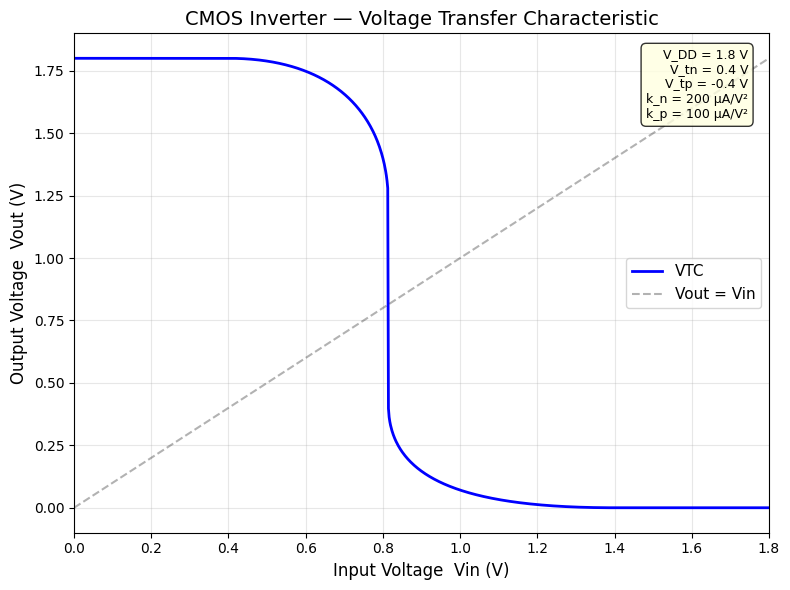

In [14]:
# ── Compute VTC ───────────────────────────────────────────────

Vin = np.linspace(0, V_DD, 1000)
Vout = np.array([solve_vout(v) for v in Vin])

# ── Plot ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(Vin, Vout, 'b-', linewidth=2, label='VTC')
ax.plot([0, V_DD], [0, V_DD], 'k--', alpha=0.3, label='Vout = Vin')

ax.set_xlabel('Input Voltage  Vin (V)', fontsize=12)
ax.set_ylabel('Output Voltage  Vout (V)', fontsize=12)
ax.set_title('CMOS Inverter — Voltage Transfer Characteristic', fontsize=14)
ax.set_xlim(0, V_DD)
ax.set_ylim(-0.1, V_DD + 0.1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

ax.annotate(f'V_DD = {V_DD} V\nV_tn = {V_tn} V\nV_tp = {V_tp} V\nk_n = {k_n} µA/V²\nk_p = {k_p} µA/V²',
            xy=(0.97, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(figures_dir / "vtc.png", dpi=150)
plt.show()

In [15]:
# Gain = dVout/dVin (numerical derivative)
gain = np.gradient(Vout, Vin)

# V_M — switching threshold: point where Vout is closest to Vin
vm_idx = np.argmin(np.abs(Vout - Vin))
V_M = Vin[vm_idx]

# V_IL — lower slope=-1 crossing (left side of transition)
# V_IH — upper slope=-1 crossing (right side of transition)
slope_plus1 = gain + 1          # zero-crossings where gain = -1
sign_changes = np.where(np.diff(np.sign(slope_plus1)))[0]
# Expect at least 2 crossings; take first as V_IL, last as V_IH
V_IL = Vin[sign_changes[0]]
V_IH = Vin[sign_changes[-1]]

# V_OH / V_OL — rail voltages (ideal for long-channel model)
V_OH = Vout[0]      # output when Vin = 0 (PMOS fully on)
V_OL = Vout[-1]     # output when Vin = V_DD (NMOS fully on)

# Noise margins
NM_H = V_OH - V_IH
NM_L = V_IL - V_OL

# Print table
print(f"{'Parameter':<8} {'Value':>10}   {'Definition'}")
print("-" * 55)
print(f"{'V_OH':<8} {V_OH:>9.4f} V  Output high voltage")
print(f"{'V_OL':<8} {V_OL:>9.4f} V  Output low voltage")
print(f"{'V_M':<8} {V_M:>9.4f} V  Switching threshold (Vout=Vin)")
print(f"{'V_IL':<8} {V_IL:>9.4f} V  Input low  (gain = -1, lower)")
print(f"{'V_IH':<8} {V_IH:>9.4f} V  Input high (gain = -1, upper)")
print(f"{'NM_H':<8} {NM_H:>9.4f} V  Noise Margin High (V_OH - V_IH)")
print(f"{'NM_L':<8} {NM_L:>9.4f} V  Noise Margin Low  (V_IL - V_OL)")

Parameter      Value   Definition
-------------------------------------------------------
V_OH        1.8000 V  Output high voltage
V_OL        0.0000 V  Output low voltage
V_M         0.8144 V  Switching threshold (Vout=Vin)
V_IL        0.6649 V  Input low  (gain = -1, lower)
V_IH        0.9117 V  Input high (gain = -1, upper)
NM_H        0.8883 V  Noise Margin High (V_OH - V_IH)
NM_L        0.6649 V  Noise Margin Low  (V_IL - V_OL)


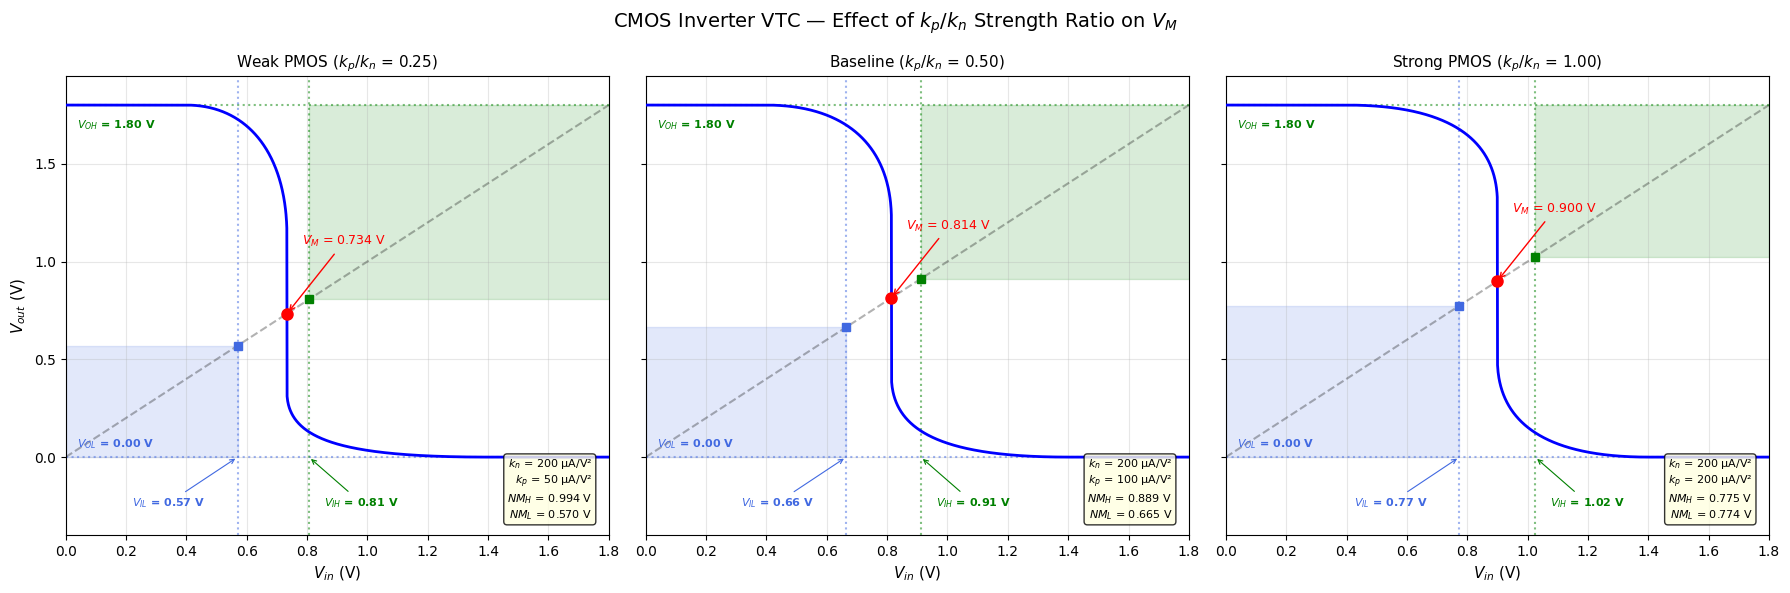

In [16]:
# ── VTC Comparison: Effect of k_p/k_n Strength Ratio on V_M ──

ratios = [
    (0.25, 'Weak PMOS ($k_p/k_n$ = 0.25)'),
    (0.50, 'Baseline ($k_p/k_n$ = 0.50)'),
    (1.00, 'Strong PMOS ($k_p/k_n$ = 1.00)'),
]

Vin_arr = np.linspace(0, V_DD, 2000)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for idx, (ratio, label) in enumerate(ratios):
    kp_val = ratio * k_n
    Vout_arr = np.array([solve_vout(v, kp=kp_val) for v in Vin_arr])

    # Compute gain (dVout/dVin)
    gain = np.gradient(Vout_arr, Vin_arr)

    # Find V_M (where Vout crosses Vin)
    vm_idx = np.argmin(np.abs(Vout_arr - Vin_arr))
    vm_val = Vin_arr[vm_idx]

    # Find V_IL and V_IH (where gain = -1)
    slope_plus1 = gain + 1
    sign_changes = np.where(np.diff(np.sign(slope_plus1)))[0]
    vil = Vin_arr[sign_changes[0]] if len(sign_changes) >= 1 else 0
    vih = Vin_arr[sign_changes[-1]] if len(sign_changes) >= 2 else V_DD

    # V_OH and V_OL (rail voltages)
    voh = Vout_arr[0]
    vol = Vout_arr[-1]

    # Noise margins
    nm_h = voh - vih
    nm_l = vil - vol

    ax = axes[idx]
    ax.plot(Vin_arr, Vout_arr, 'b-', linewidth=2, label='VTC', zorder=3)
    ax.plot([0, V_DD], [0, V_DD], 'k--', alpha=0.3)

    # Shade NM_H region
    ax.fill_between([vih, V_DD], voh, vih, alpha=0.15, color='green')

    # Shade NM_L region
    ax.fill_between([0, vil], vol, vil, alpha=0.15, color='royalblue')

    # --- V_OH line and label ---
    ax.axhline(voh, color='green', linestyle=':', alpha=0.5)
    ax.annotate(f'$V_{{OH}}$ = {voh:.2f} V',
                xy=(0.0, voh), xytext=(0.02, voh - 0.12),
                fontsize=8, color='green', fontweight='bold',
                xycoords=('axes fraction', 'data'))

    # --- V_OL line and label ---
    ax.axhline(vol, color='royalblue', linestyle=':', alpha=0.5)
    ax.annotate(f'$V_{{OL}}$ = {vol:.2f} V',
                xy=(0.0, vol), xytext=(0.02, vol + 0.05),
                fontsize=8, color='royalblue', fontweight='bold',
                xycoords=('axes fraction', 'data'))

    # --- V_IL line and label ---
    ax.axvline(vil, color='royalblue', linestyle=':', alpha=0.5)
    ax.plot(vil, vil, 's', color='royalblue', markersize=6, zorder=4)
    ax.annotate(f'$V_{{IL}}$ = {vil:.2f} V',
                xy=(vil, 0), xytext=(vil - 0.35, -0.25),
                fontsize=8, color='royalblue', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='royalblue', lw=0.8))

    # --- V_IH line and label ---
    ax.axvline(vih, color='green', linestyle=':', alpha=0.5)
    ax.plot(vih, vih, 's', color='green', markersize=6, zorder=4)
    ax.annotate(f'$V_{{IH}}$ = {vih:.2f} V',
                xy=(vih, 0), xytext=(vih + 0.05, -0.25),
                fontsize=8, color='green', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green', lw=0.8))

    # Mark V_M
    ax.plot(vm_val, vm_val, 'ro', markersize=8, zorder=4)
    ax.annotate(f'$V_M$ = {vm_val:.3f} V', xy=(vm_val, vm_val),
                xytext=(vm_val + 0.05, vm_val + 0.35), fontsize=9, color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

    ax.set_xlabel('$V_{in}$ (V)', fontsize=11)
    if idx == 0:
        ax.set_ylabel('$V_{out}$ (V)', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, V_DD)
    ax.set_ylim(-0.4, V_DD + 0.15)
    ax.grid(True, alpha=0.3)

    # Parameter + noise margin info box
    ax.annotate(
        f'$k_n$ = {k_n} µA/V²\n$k_p$ = {kp_val:.0f} µA/V²\n'
        f'$NM_H$ = {nm_h:.3f} V\n$NM_L$ = {nm_l:.3f} V',
        xy=(0.97, 0.03), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8))

fig.suptitle('CMOS Inverter VTC — Effect of $k_p/k_n$ Strength Ratio on $V_M$', fontsize=14)
plt.tight_layout()
plt.savefig(figures_dir / "vtc_kp_kn_ratio.png", dpi=150)
plt.show()

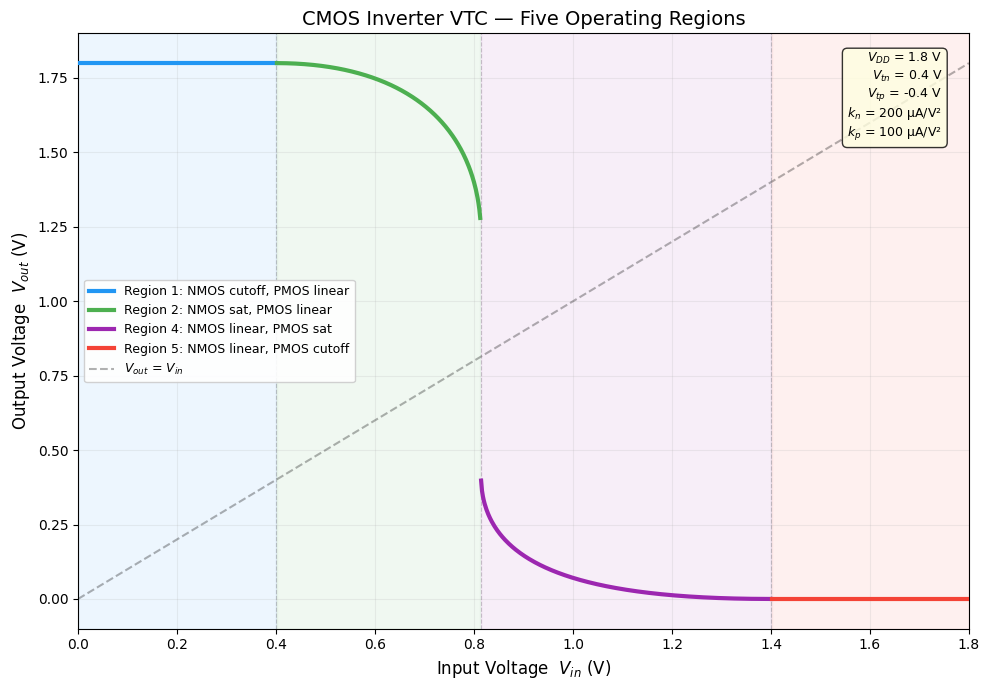

In [17]:
# ── VTC with 5 Operating Regions ──────────────────────────────
# Region 1: Vin < V_tn                → NMOS cutoff,  PMOS linear   → Vout ≈ V_DD
# Region 2: NMOS sat, PMOS linear     → Vout starts to drop
# Region 3: NMOS sat, PMOS sat        → transition (high gain)
# Region 4: NMOS linear, PMOS sat     → Vout approaches 0
# Region 5: Vin > V_DD + V_tp         → NMOS linear,  PMOS cutoff   → Vout ≈ 0

# Classify each (Vin, Vout) point into a region
regions = []
for vin, vout in zip(Vin, Vout):
    Vgsn = vin
    Vdsn = vout
    Vsgp = V_DD - vin
    Vsdp = V_DD - vout

    nmos_off = Vgsn - V_tn <= 0
    pmos_off = Vsgp + V_tp <= 0  # Vsgp < |V_tp|

    if nmos_off:
        regions.append(1)
    elif pmos_off:
        regions.append(5)
    else:
        nmos_sat = Vdsn >= Vgsn - V_tn
        pmos_sat = Vsdp >= Vsgp + V_tp

        if nmos_sat and not pmos_sat:
            regions.append(2)
        elif nmos_sat and pmos_sat:
            regions.append(3)
        else:
            regions.append(4)

regions = np.array(regions)

# ── Plot ──────────────────────────────────────────────────────

region_info = {
    1: ('Region 1', 'NMOS cutoff, PMOS linear', '#2196F3'),
    2: ('Region 2', 'NMOS sat, PMOS linear', '#4CAF50'),
    3: ('Region 3', 'NMOS sat, PMOS sat', '#FF9800'),
    4: ('Region 4', 'NMOS linear, PMOS sat', '#9C27B0'),
    5: ('Region 5', 'NMOS linear, PMOS cutoff', '#F44336'),
}

fig, ax = plt.subplots(figsize=(10, 7))

# Plot each region as a colored segment
for r in [1, 2, 3, 4, 5]:
    mask = regions == r
    if not np.any(mask):
        continue
    name, desc, color = region_info[r]
    ax.plot(Vin[mask], Vout[mask], color=color, linewidth=3,
            label=f'{name}: {desc}', zorder=3)

    # Shade the region's Vin range
    vin_min, vin_max = Vin[mask].min(), Vin[mask].max()
    ax.axvspan(vin_min, vin_max, alpha=0.08, color=color)

ax.plot([0, V_DD], [0, V_DD], 'k--', alpha=0.3, label='$V_{out}$ = $V_{in}$')

# Mark region boundaries with vertical lines
for i in range(len(regions) - 1):
    if regions[i] != regions[i + 1]:
        boundary_vin = (Vin[i] + Vin[i + 1]) / 2
        ax.axvline(boundary_vin, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

ax.set_xlabel('Input Voltage  $V_{in}$ (V)', fontsize=12)
ax.set_ylabel('Output Voltage  $V_{out}$ (V)', fontsize=12)
ax.set_title('CMOS Inverter VTC — Five Operating Regions', fontsize=14)
ax.set_xlim(0, V_DD)
ax.set_ylim(-0.1, V_DD + 0.1)
ax.grid(True, alpha=0.2)
ax.legend(loc='center left', fontsize=9, framealpha=0.9)

ax.annotate(f'$V_{{DD}}$ = {V_DD} V\n$V_{{tn}}$ = {V_tn} V\n$V_{{tp}}$ = {V_tp} V\n'
            f'$k_n$ = {k_n} µA/V²\n$k_p$ = {k_p} µA/V²',
            xy=(0.97, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(figures_dir / "vtc_five_regions.png", dpi=150)
plt.show()